In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## NOAA = National Oceanic and Atmospheric Administration  
- It’s a U.S. federal agency under the Department of Commerce.

#### Think of NOAA as:

- the source of all official U.S. weather alerts

- the organization that tracks storms, hurricanes, floods, wildfires, heatwaves

- the provider of real‑time weather APIs

- the authority behind emergency alerts used by FEMA, airlines, and local governments

- When your phone shows:

- Severe Thunderstorm Warning

- Flash Flood Emergency

- Tornado Watch

- Those alerts originate from NOAA.

### NOAA Weather Alerts Summary — Full Python ETL Example
#### This pipeline:
```
Calls the NOAA Weather Alerts API

Normalizes deeply nested JSON

Extracts key alert fields

Cleans timestamps

Aggregates alerts by severity and region

Writes a summary file

Produces one visualization (alerts by severity)
```

Total alerts received: 263
Normalized rows: 263
Summary file written: noaa_weather_summary.txt


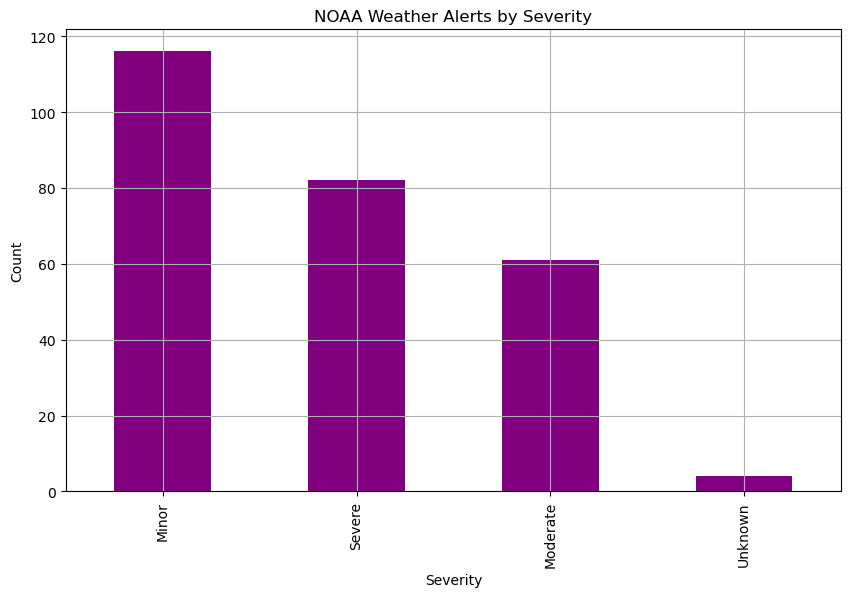

In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ============================
# Step 1: API Ingestion
# ============================

url = "https://api.weather.gov/alerts/active"
response = requests.get(url, headers={"User-Agent": "ETL-Demo"})
data = response.json()

features = data.get("features", [])
print("Total alerts received:", len(features))

# ============================
# Step 2: Normalize JSON
# ============================

records = []
for item in features:
    props = item.get("properties", {})
    
    record = {
        "id": props.get("id"),
        "area": props.get("areaDesc"),
        "event": props.get("event"),
        "severity": props.get("severity"),
        "certainty": props.get("certainty"),
        "urgency": props.get("urgency"),
        "effective": props.get("effective"),
        "expires": props.get("expires"),
        "sender": props.get("senderName"),
        "headline": props.get("headline"),
        "description": props.get("description"),
    }
    records.append(record)

df = pd.DataFrame(records)
print("Normalized rows:", len(df))

# ============================
# Step 3: ETL Transformations
# ============================

# Clean timestamps
df["effective"] = pd.to_datetime(df["effective"], errors="coerce")
df["expires"] = pd.to_datetime(df["expires"], errors="coerce")

# Safe duration calculation
def compute_duration(row):
    if pd.isna(row["effective"]) or pd.isna(row["expires"]):
        return None
    return (row["expires"] - row["effective"]).total_seconds() / 3600

df["duration_hours"] = df.apply(compute_duration, axis=1)

# Extract primary region (first listed area)
df["primary_region"] = df["area"].str.split(";").str[0]

# Fill missing severity
df["severity"] = df["severity"].fillna("Unknown")


# ============================
# Step 4: Summary Aggregation
# ============================

summary = {
    "total_alerts": len(df),
    "alerts_by_severity": df["severity"].value_counts().to_dict(),
    "alerts_by_region": df["primary_region"].value_counts().head(10).to_dict(),
    "average_duration_hours": df["duration_hours"].mean(),
    "max_duration_hours": df["duration_hours"].max(),
}

# ============================
# Step 5: Write Summary File
# ============================

with open("noaa_weather_summary.txt", "w") as f:
    f.write("NOAA Weather Alerts Summary\n")
    f.write("===========================\n\n")
    f.write(f"Total Alerts: {summary['total_alerts']}\n\n")
    
    f.write("Alerts by Severity:\n")
    for k, v in summary["alerts_by_severity"].items():
        f.write(f"  {k}: {v}\n")
    f.write("\n")
    
    f.write("Top 10 Regions:\n")
    for k, v in summary["alerts_by_region"].items():
        f.write(f"  {k}: {v}\n")
    f.write("\n")
    
    f.write(f"Average Duration (hours): {summary['average_duration_hours']:.2f}\n")
    f.write(f"Max Duration (hours): {summary['max_duration_hours']:.2f}\n")

print("Summary file written: noaa_weather_summary.txt")

# ============================
# Step 6: Visualization
# ============================

plt.figure(figsize=(10,6))
df["severity"].value_counts().plot(kind="bar", color="purple")
plt.title("NOAA Weather Alerts by Severity")
plt.xlabel("Severity")
plt.ylabel("Count")
plt.grid(True)
plt.show()


### severity heatmap
- “Which regions are experiencing the most severe weather right now?”

- A severity heatmap is a colored grid that shows:

✔ Rows → Regions (states, counties, or NOAA areas)

✔ Columns → Severity levels (Severe, Moderate, Minor, Unknown)

✔ Cell color → Number of alerts in that region at that severity

### Severity Heatmap — What It Shows
Rows → Regions (primary_region)

Columns → Severity levels (Severe, Moderate, Minor, Unknown)

Cell color → Number of alerts in that region at that severity

## What This Heatmap Gives You
- Dark red = region with many severe alerts

- Light red = region with few alerts

- White = no alerts

- Annotated numbers = exact alert counts

This is a professional‑grade risk visualization used by emergency management teams.

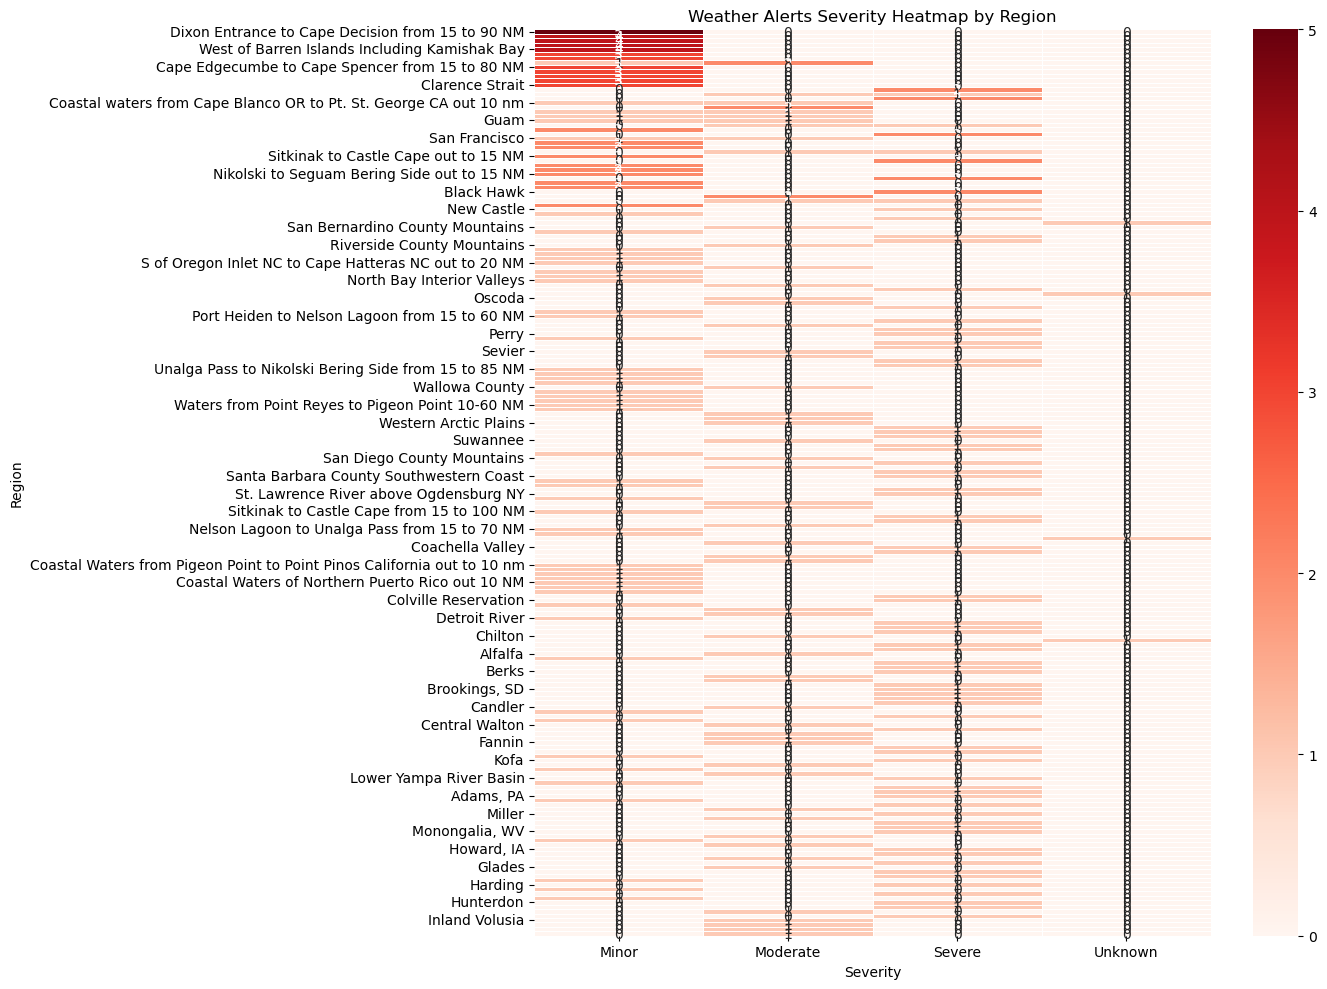

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot table: region vs severity
heatmap_data = df.pivot_table(
    index="primary_region",
    columns="severity",
    values="id",
    aggfunc="count",
    fill_value=0
)

# Sort by total alerts (optional, makes heatmap cleaner)
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    cmap="Reds",
    linewidths=0.5,
    annot=True,
    fmt="d"
)

plt.title("Weather Alerts Severity Heatmap by Region")
plt.xlabel("Severity")
plt.ylabel("Region")
plt.tight_layout()
plt.show()
